In [1]:
# train on almost the entire dataset
# train again, using the suspcion values

In [2]:
import pandas as pd
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import LeaveOneOut

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import classification_report, f1_score
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import matplotlib.pyplot as plt
import matplotlib as mpl
# pip install umap-learn
from matplotlib.cm import get_cmap
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler
import umap.umap_ as umap
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import shap
import warnings
import os

In [3]:
output_dir = '/home/dg204/park_dglodzik/SVsigs/classifier/PCAWG_training/'
os.makedirs(output_dir, exist_ok=True)

In [4]:
labels_fn='/home/dg204/projects/rsignatures/data/processed/pcawg_labels_v2.csv'
# see RFD_SigPlots
if labels_fn!=None:
    pb_labels = pd.read_csv(labels_fn, index_col=0)
    pb_labels.shape

    

In [5]:
pb_labels.shape

(3082, 3)

In [6]:
# see RTime_fitting
H_comb = pd.read_csv('/home/dg204/projects/rsignatures/data/processed/H_comb.csv', index_col=0)

In [7]:
H_comb.shape

(33, 631)

In [8]:
H_comb.T.head(1)

,Signature 1_RFD,Signature 2_RFD,Signature 3_RFD,Signature 4_RFD,Signature 5_RFD,Signature 6_RFD,Signature 7_RFD,Signature 8_RFD,Signature 9_RFD,Signature 10_RFD,...,Signature 9_RT,Signature 10_RT,Signature 11_RT,Signature 12_RT,Signature 13_RT,Signature 14_RT,Signature 15_RT,Signature 16_RT,Signature 17_RT,Signature 18_RT
f39cc911-36a7-4c06-9e91-4ad86281db3d,0.0,0.0,0.0,0.0,1.19062,0.0,0.0,1.292076,0.0,0.0,...,1.391166,0.0,0.0,0.0,0.0,0.0,0.0,2.101606,0.0,2.423464


In [9]:
pb_labels.head(1)

,label,HRDetect,HRD_label
983c14b8-f35b-497b-9fd4-5e5f5f0a7aa7,other,0.00328,HRP


In [10]:
pb_labels_matched = pb_labels.loc[H_comb.columns]

In [11]:
pb_labels_matched.shape

(631, 3)

In [12]:
pb_labels_matched['label'].value_counts()

label
other    554
CCNE1     41
BRCA1     18
BRCA2     13
CDK12      5
Name: count, dtype: int64

In [13]:
X=H_comb.T
y=pb_labels_matched.loc[H_comb.columns,'label']

In [14]:
labels = np.unique(y)
le = LabelEncoder().fit(labels)
n_classes = len(labels)


In [15]:
classes = np.unique(y)
class_weights = compute_class_weight(
    class_weight="balanced",  # inversely proportional to frequency
    classes=classes,
    y=y
)
class_weight_dict = dict(zip(classes, class_weights))
print(class_weight_dict)

{'BRCA1': np.float64(7.011111111111111), 'BRCA2': np.float64(9.707692307692307), 'CCNE1': np.float64(3.078048780487805), 'CDK12': np.float64(25.24), 'other': np.float64(0.22779783393501804)}


In [16]:
class_weight_dict['BRCA1'] = 3 * class_weight_dict['BRCA1'] 
class_weight_dict['BRCA2'] = 3 * class_weight_dict['BRCA2'] 
class_weight_dict['CCNE1'] = 3 * class_weight_dict['CCNE1'] 
sample_weights = np.array([class_weight_dict[c] for c in y])

In [17]:
params_base = dict(
    objective="multi:softprob",
    num_class=n_classes,
    eval_metric="mlogloss",
    learning_rate=0.05,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.5,
    n_estimators=50,
    random_state=42,
)

In [18]:
# =========================================================
# STEP 0: Out-of-fold probabilities on the entire dataset, leave-one-out
# =========================================================

loo = LeaveOneOut()


X_np=X.to_numpy()
y_enc=le.transform(y)


oof_proba = np.zeros((len(y), n_classes))
# loop over leave-one-out folds
for tr_idx, val_idx in loo.split(X_np, y_enc):
    clf = xgb.XGBClassifier(**params_base, n_jobs=-1)
    
    # fit model
    clf.fit(
        X_np[tr_idx],
        y_enc[tr_idx],
        sample_weight=sample_weights[tr_idx]
    )
    
    # predict on the left-out sample
    oof_proba[val_idx] = clf.predict_proba(X_np[val_idx])


In [19]:
four_labels = ["BRCA1", "BRCA2", "CCNE1", "CDK12"]
best_idx = oof_proba.argmax(axis=1)
y_pred = le.inverse_transform(best_idx)
print(classification_report(y, y_pred, digits=3))

              precision    recall  f1-score   support

       BRCA1      0.219     0.778     0.341        18
       BRCA2      0.323     0.769     0.455        13
       CCNE1      0.201     0.780     0.320        41
       CDK12      0.571     0.800     0.667         5
       other      0.978     0.653     0.784       554

    accuracy                          0.669       631
   macro avg      0.458     0.756     0.513       631
weighted avg      0.889     0.669     0.733       631



/n/data1/hms/dbmi/park/dglodzik/envs/jupytervenv3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_1656522/418167857.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = get_cmap("tab20" if n_classes > 10 else "tab10")


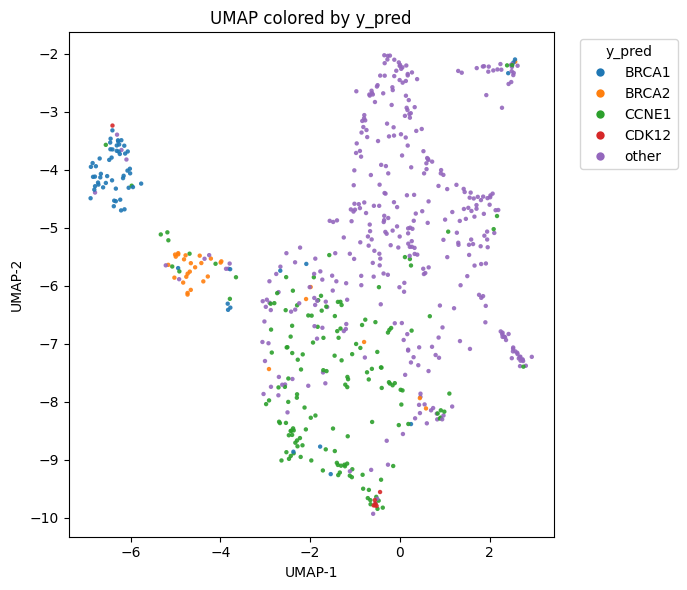

In [20]:

# --- Inputs ---
# X: pandas DataFrame (n_samples x n_features)
# y_pred: array-like or pd.Series of length n_samples

# 1) Standardize features (recommended for UMAP)
X_std = StandardScaler().fit_transform(X.values)

# 2) Compute UMAP embedding
umap_model = umap.UMAP(
    n_neighbors=15,     # tweak: local vs global structure
    min_dist=0.1,       # tweak: cluster tightness
    metric="euclidean",
    random_state=42
)
embedding = umap_model.fit_transform(X_std)   # shape (n_samples, 2)

# 3) Prepare labels (categorical-safe)
y_pred = pd.Series(y_pred).astype("category")
classes = list(y_pred.cat.categories)
codes = y_pred.cat.codes.values  # int codes 0..n_classes-1
n_classes = len(classes)

# Colormap (up to 20 distinct colors by default)
base = get_cmap("tab20" if n_classes > 10 else "tab10")
cmap = ListedColormap(base.colors[:n_classes])

# 4) Plot
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=codes,
    s=10,                # increase if you have fewer points
    alpha=0.9,
    cmap=cmap,
    edgecolor="none"
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP colored by y_pred")

# Legend
handles = []
for i, cls in enumerate(classes):
    handles.append(plt.Line2D([0], [0], marker='o', linestyle='',
                              markerfacecolor=cmap(i), markeredgecolor='none', label=str(cls)))
plt.legend(handles=handles, title="y_pred", bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()


In [21]:
# probability assigned to the *true* class for each sample
p_true = oof_proba[np.arange(len(y)), y_enc]

# handy diagnostics
y_pred_enc = oof_proba.argmax(axis=1)
p_predmax = oof_proba.max(axis=1)
suspicion = 1.0 - p_true                  # low p_true ⇒ high suspicion
margin = p_predmax - p_true               # how much the top class beats the true class


# table of most suspicious samples
import pandas as pd
df_audit = pd.DataFrame({
    "idx": np.arange(len(y_enc)),
    "y_true_enc": y_enc,
    "y_pred_enc": y_pred_enc,
    "p_true": p_true,
    "p_predmax": p_predmax,
    "margin": margin
}).sort_values("p_true", ascending=True)

df_audit['y_true'] = le.inverse_transform(df_audit['y_true_enc'])
df_audit['y_pred'] = le.inverse_transform(df_audit['y_pred_enc']) 
df_audit['sample_id'] = X.index[df_audit['idx']]

top_k = 50
df_audit.head(top_k).head(2)

,idx,y_true_enc,y_pred_enc,p_true,p_predmax,margin,y_true,y_pred,sample_id
347,347,1,4,0.028303,0.849747,0.821444,BRCA2,other,7ae9b843-488f-459c-8c0d-c81dcae57f99
231,231,4,0,0.038159,0.873832,0.835673,other,BRCA1,4679f37a-4f09-449b-a1d8-1f02847996da


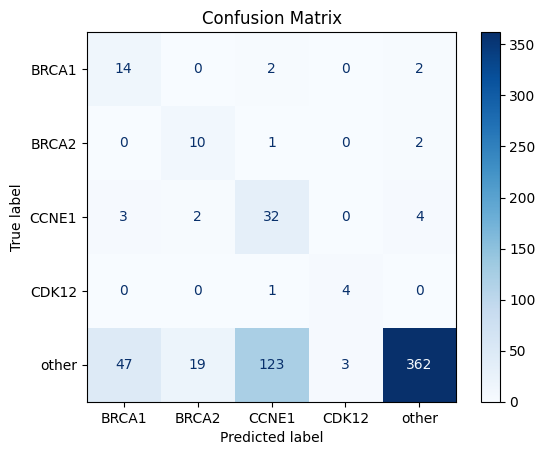

In [22]:
cm = confusion_matrix(df_audit['y_true'], df_audit['y_pred'])
# Extract unique labels in desired order
labels = sorted(df_audit['y_true'].unique())

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

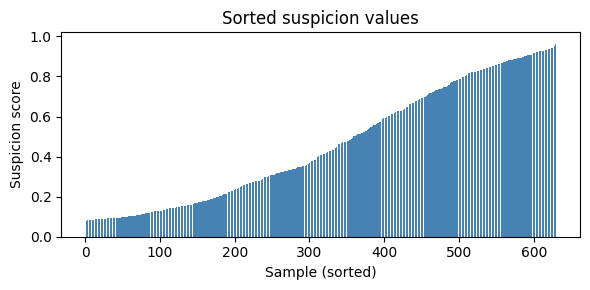

In [23]:
sorted_idx = np.argsort(suspicion)
sorted_vals = suspicion[sorted_idx]

# plot
plt.figure(figsize=(6, 3))
plt.bar(range(len(sorted_vals)), sorted_vals, color="steelblue")
plt.xlabel("Sample (sorted)")
plt.ylabel("Suspicion score")
plt.title("Sorted suspicion values")
plt.tight_layout()
plt.show()

In [47]:
cut = np.percentile(suspicion, 90)
sample_weights_susp = np.ones_like(suspicion)
#sample_weights_susp[suspicion >= cut] = 0.4
sample_weights_susp[suspicion >= cut] = 0.8

In [48]:
oof_proba_2 = np.zeros((len(y), n_classes))
# loop over leave-one-out folds
for tr_idx, val_idx in loo.split(X_np, y_enc):
    clf = xgb.XGBClassifier(**params_base, n_jobs=-1)
    
    # fit model
    clf.fit(
        X_np[tr_idx],
        y_enc[tr_idx],
        sample_weight=sample_weights[tr_idx] * sample_weights_susp[tr_idx]
    )
    
    # predict on the left-out sample
    oof_proba_2[val_idx] = clf.predict_proba(X_np[val_idx])

In [49]:
#clf.save_model("/home/dg204/projects/rsignatures/data/processed/model.json")

In [50]:
# handy diagnostics
y_pred_enc_2 = oof_proba_2.argmax(axis=1)
p_predmax_2 = oof_proba_2.max(axis=1)
p_true = oof_proba_2[np.arange(len(y)), y_enc]
suspicion_2 = 1.0 - p_true                  # low p_true ⇒ high suspicion
margin_2 = p_predmax_2 - p_true               # how much the top class beats the true class

# table of most suspicious samples

df_audit_2 = pd.DataFrame({
    "idx": np.arange(len(y_enc)),
    "y_true_enc": y_enc,
    "y_pred_enc": y_pred_enc_2,
    "p_true": p_true,
    "p_predmax": p_predmax,
    "margin": margin_2
}).sort_values("p_true", ascending=True)

df_audit_2['y_true'] = le.inverse_transform(df_audit_2['y_true_enc'])
df_audit_2['y_pred'] = le.inverse_transform(df_audit_2['y_pred_enc']) 
df_audit_2['sample_id'] = X.index[df_audit_2['idx']]

top_k = 50
df_audit.head(top_k).head(2)

,idx,y_true_enc,y_pred_enc,p_true,p_predmax,margin,y_true,y_pred,sample_id
347,347,1,4,0.028303,0.849747,0.821444,BRCA2,other,7ae9b843-488f-459c-8c0d-c81dcae57f99
231,231,4,0,0.038159,0.873832,0.835673,other,BRCA1,4679f37a-4f09-449b-a1d8-1f02847996da


In [51]:
four_labels = ["BRCA1", "BRCA2", "CCNE1", "CDK12"]
best_idx = oof_proba_2.argmax(axis=1)
y_pred_2 = le.inverse_transform(y_pred_enc_2)

print(classification_report(y, y_pred_2, digits=3))

              precision    recall  f1-score   support

       BRCA1      0.215     0.778     0.337        18
       BRCA2      0.333     0.769     0.465        13
       CCNE1      0.203     0.780     0.322        41
       CDK12      0.571     0.800     0.667         5
       other      0.976     0.653     0.783       554

    accuracy                          0.669       631
   macro avg      0.460     0.756     0.515       631
weighted avg      0.887     0.669     0.733       631



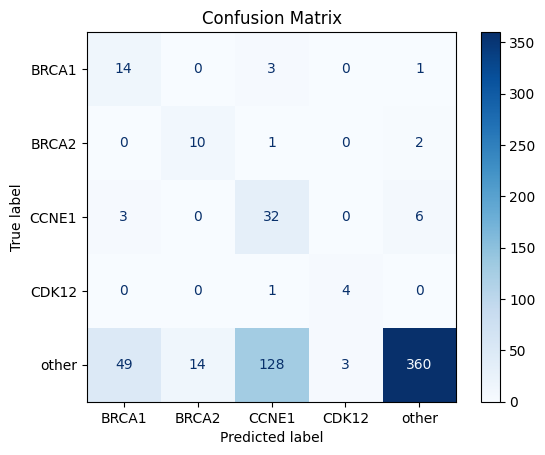

In [45]:
cm2 = confusion_matrix(df_audit_2['y_true'], df_audit_2['y_pred'])
# Extract unique labels in desired order
labels = sorted(df_audit_2['y_true'].unique())

# Display
disp = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=labels)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import Normalize
from matplotlib.cm import get_cmap
from sklearn.metrics import confusion_matrix
import os

# --- Compute confusion matrix ---
cm2 = confusion_matrix(df_audit_2['y_true'], df_audit_2['y_pred'])
# Extract unique labels in desired order
labels = sorted(df_audit_2['y_true'].unique())

# --- Figure setup ---
fig, ax = plt.subplots(figsize=(4, 4))
ax.set_aspect('equal')

# --- Define colormap ---
cmap = get_cmap("Blues")
norm = Normalize(vmin=0, vmax=cm.max())

# --- Draw each cell as a solid rectangle (no transparency) ---
n_rows, n_cols = cm.shape
for i in range(n_rows):
    for j in range(n_cols):
        val = cm[i, j]
        color = cmap(norm(val))
        color = (color[0], color[1], color[2], 1.0)  # force full opacity
        rect = Rectangle((j, i), 1, 1, facecolor=color,
                         edgecolor='black', linewidth=0.5)
        ax.add_patch(rect)
        ax.text(j + 0.5, i + 0.5, str(val),
                ha='center', va='center', color='black', fontsize=10)

# --- Axes and labels ---
ax.set_xlim(0, n_cols)
ax.set_ylim(n_rows, 0)  # invert y-axis so top-left is (0,0)
ax.set_xticks(np.arange(n_cols) + 0.5)
ax.set_yticks(np.arange(n_rows) + 0.5)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
plt.title("Confusion Matrix", fontsize=14)

# --- Clean up axes ---
for spine in ax.spines.values():
    spine.set_linewidth(1.0)

plt.tight_layout()

# --- Save as fully vector PDF ---
output_path = os.path.join(output_dir, "confusion_matrix_leave_one_out.pdf")
plt.savefig(output_path, format="pdf", bbox_inches="tight", transparent=False)
plt.close(fig)

print(f"✅ Saved fully vector, Illustrator-editable PDF: {output_path}")

plt.show()

✅ Saved fully vector, Illustrator-editable PDF: /home/dg204/park_dglodzik/SVsigs/classifier/PCAWG_training/confusion_matrix_leave_one_out.pdf


/tmp/ipykernel_1656522/2402668802.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = get_cmap("Blues")


/n/data1/hms/dbmi/park/dglodzik/envs/jupytervenv3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_1656522/2534065972.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = get_cmap("tab20" if n_classes > 10 else "tab10")


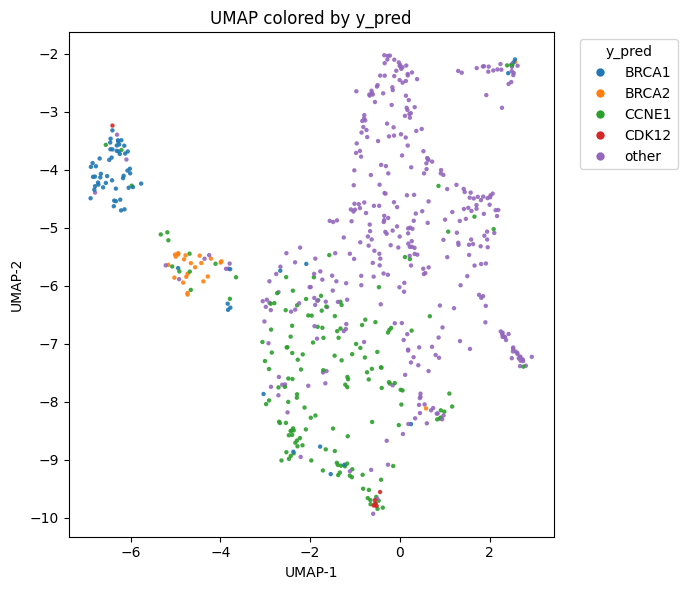

In [31]:


# --- Inputs ---
# X: pandas DataFrame (n_samples x n_features)
# y_pred: array-like or pd.Series of length n_samples

# 1) Standardize features (recommended for UMAP)
X_std = StandardScaler().fit_transform(X.values)

# 2) Compute UMAP embedding
umap_model = umap.UMAP(
    n_neighbors=15,     # tweak: local vs global structure
    min_dist=0.1,       # tweak: cluster tightness
    metric="euclidean",
    random_state=42
)
embedding = umap_model.fit_transform(X_std)   # shape (n_samples, 2)

# 3) Prepare labels (categorical-safe)
y_pred_2 = pd.Series(y_pred_2).astype("category")
classes = list(y_pred_2.cat.categories)
codes = y_pred_2.cat.codes.values  # int codes 0..n_classes-1
n_classes = len(classes)

# Colormap (up to 20 distinct colors by default)
base = get_cmap("tab20" if n_classes > 10 else "tab10")
cmap = ListedColormap(base.colors[:n_classes])

# 4) Plot
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=codes,
    s=10,                # increase if you have fewer points
    alpha=0.9,
    cmap=cmap,
    edgecolor="none"
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP colored by y_pred")

# Legend
handles = []
for i, cls in enumerate(classes):
    handles.append(plt.Line2D([0], [0], marker='o', linestyle='',
                              markerfacecolor=cmap(i), markeredgecolor='none', label=str(cls)))
plt.legend(handles=handles, title="y_pred", bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()

/tmp/ipykernel_1656522/1232319999.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = get_cmap("tab20" if n_classes > 10 else "tab10")


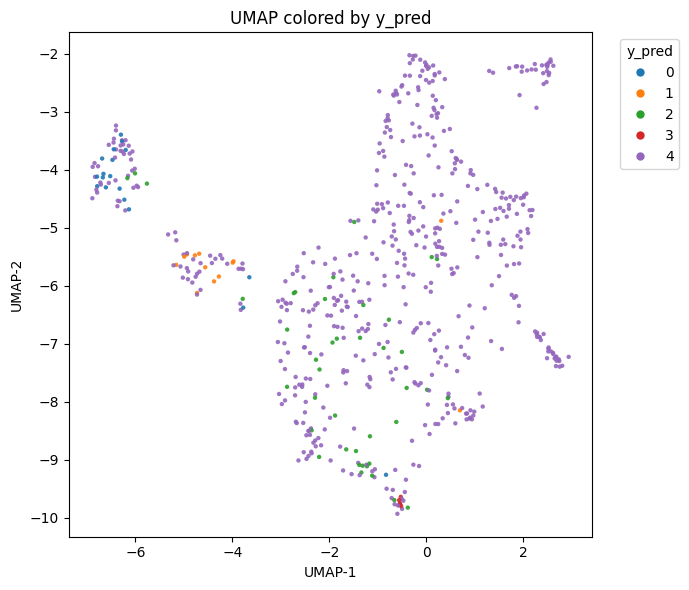

In [32]:

# 3) Prepare labels (categorical-safe)
y_pred_2 = pd.Series(y_enc).astype("category")
classes = list(y_pred_2.cat.categories)
codes = y_pred_2.cat.codes.values  # int codes 0..n_classes-1
n_classes = len(classes)

# Colormap (up to 20 distinct colors by default)
base = get_cmap("tab20" if n_classes > 10 else "tab10")
cmap = ListedColormap(base.colors[:n_classes])

# 4) Plot
plt.figure(figsize=(7, 6))
sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=codes,
    s=10,                # increase if you have fewer points
    alpha=0.9,
    cmap=cmap,
    edgecolor="none"
)
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP colored by y_pred")

# Legend
handles = []
for i, cls in enumerate(classes):
    handles.append(plt.Line2D([0], [0], marker='o', linestyle='',
                              markerfacecolor=cmap(i), markeredgecolor='none', label=str(cls)))
plt.legend(handles=handles, title="y_pred", bbox_to_anchor=(1.04, 1), loc="upper left")

plt.tight_layout()
plt.show()

In [33]:
pb_labels_m = pd.merge(pb_labels, df_audit, left_index=True, right_on='sample_id', how='left')
pb_labels_m.index = pb_labels_m['sample_id']

In [34]:
pb_labels_m.head(2)

,label,HRDetect,HRD_label,idx,y_true_enc,y_pred_enc,p_true,p_predmax,margin,y_true,y_pred,sample_id
sample_id,,,,,,,,,,,,
983c14b8-f35b-497b-9fd4-5e5f5f0a7aa7,other,0.003280,HRP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,983c14b8-f35b-497b-9fd4-5e5f5f0a7aa7
a47c2012-c13d-48ac-88b6-e09bfd50122b,other,0.001535,HRP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,a47c2012-c13d-48ac-88b6-e09bfd50122b


/n/data1/hms/dbmi/park/dglodzik/envs/jupytervenv3.13/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved Illustrator-editable PDF: /home/dg204/park_dglodzik/SVsigs/classifier/PCAWG_training//umap_projection_loo.pdf


<Figure size 1500x1500 with 0 Axes>

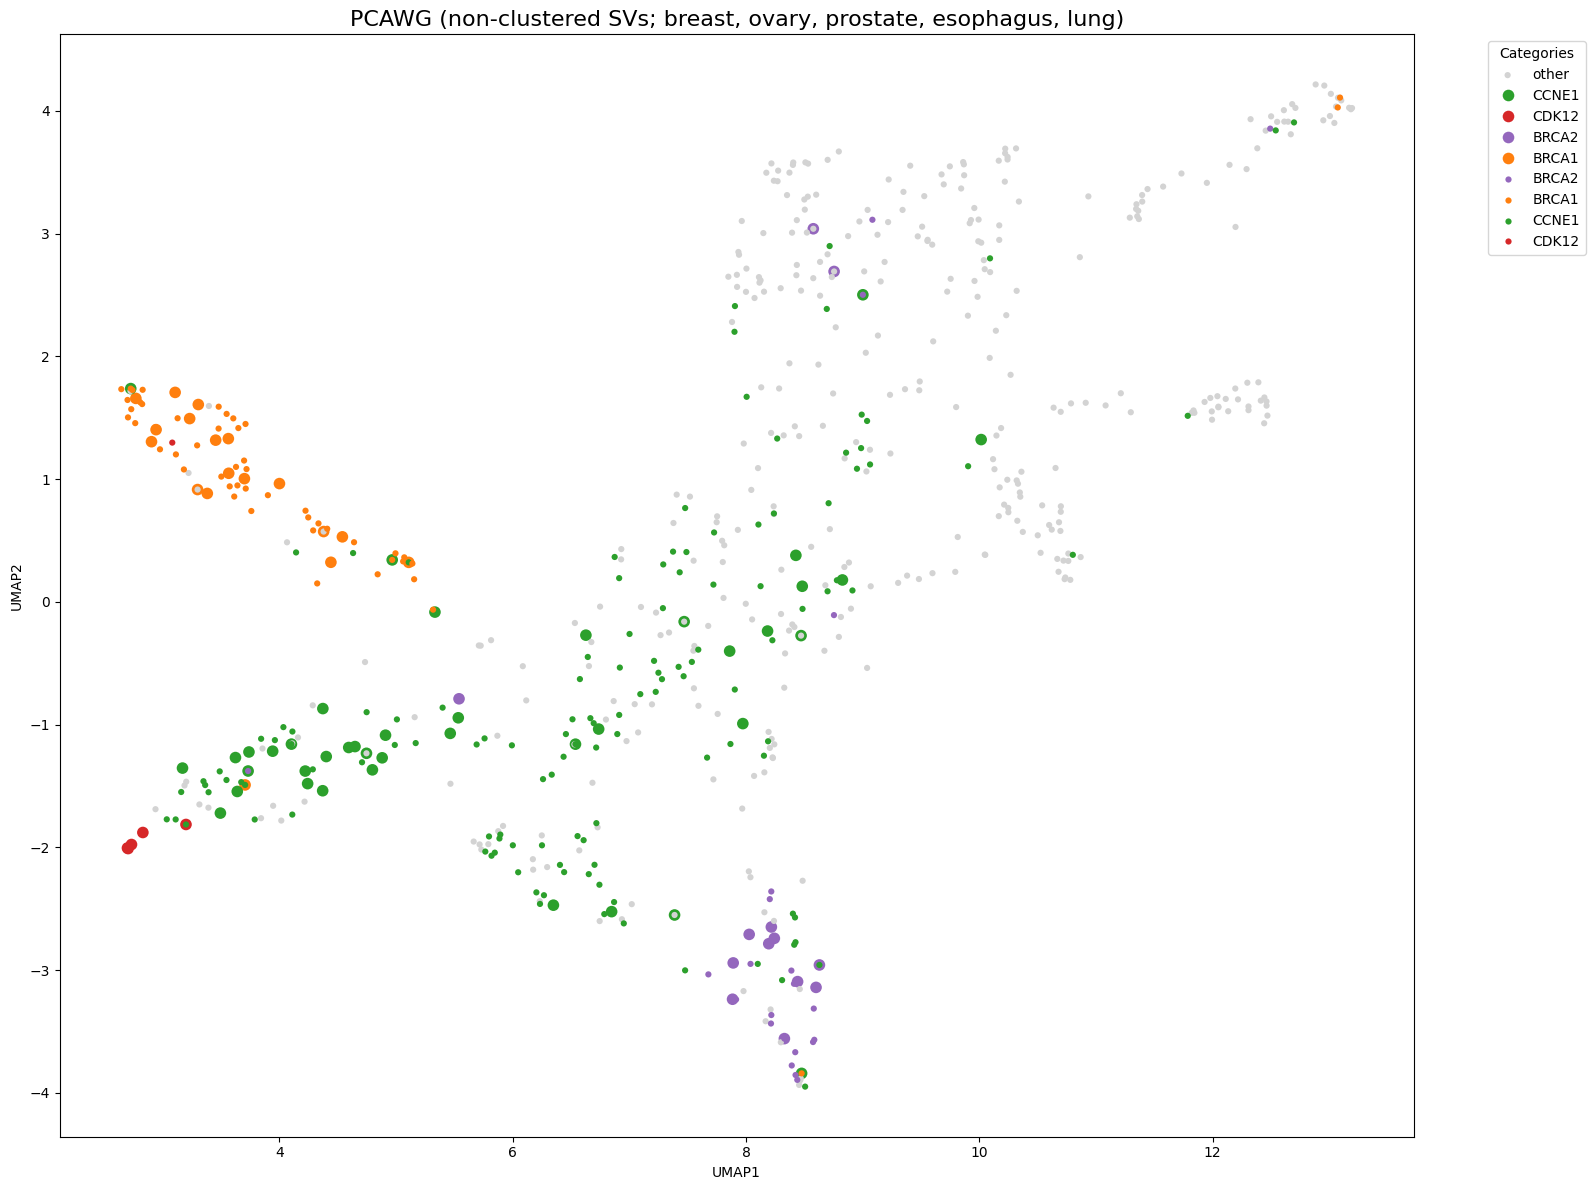

In [54]:
H_sel=X
H_sel_norm = H_sel.div(H_sel.sum(axis=1), axis=0)
plt.figure(figsize=(15, 15))

# ✅ Make text editable in Illustrator
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
H_sel_norm = H_sel_norm.loc[[i for i in H_sel_norm.index if i in pb_labels.index],:]

# --- Label mapping ---
if labels_fn is not None:
    trueLabels = pb_labels_m.loc[H_sel_norm.index, 'label']
    rowLabels = pb_labels_m.loc[H_sel_norm.index, 'y_pred']
    #rowLabels = pb_labels_m.loc[H_sel_norm.index, 'label']
    unique_labels = ['other', 'BRCA1', 'CCNE1', 'CDK12', 'BRCA2']
    palette = sns.color_palette("tab10", len(unique_labels))
    lut = dict(zip(unique_labels, palette))
    row_colors = rowLabels.map(lut)
else:
    rowLabels = None

# --- Run UMAP ---
reducer = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=42
)
embedding = reducer.fit_transform(H_sel_norm)

# --- Create DataFrame ---
umap_df = pd.DataFrame(embedding, index=H_sel_norm.index, columns=['UMAP1', 'UMAP2'])
if rowLabels is not None:
    umap_df['label'] = rowLabels.values
    umap_df['true_label'] = trueLabels.values
# --- Plot ---
plt.figure(figsize=(16, 12))

if rowLabels is not None:
    # Split into "other" and "non-other"
    df_other = umap_df[umap_df['label'] == "other"]
    df_non_other = umap_df[umap_df['label'] != "other"]
    df_mutant = umap_df[umap_df['true_label'] != "other"]
    

    plt.scatter(
        df_other['UMAP1'],
        df_other['UMAP2'],
        s=20,
        facecolors='lightgray',
        edgecolors='none',
        linewidth=0.8,
        label='other',
        zorder=2
    )

    sns.scatterplot(
        data=df_mutant,
        x='UMAP1',
        y='UMAP2',
        hue='true_label',
        palette={k: v for k, v in lut.items() if k != "other"},
        s=70,
        edgecolor='none',
        linewidth=0,
        legend=True,
        zorder=1
    )


    # Plot all non-"other" points on top
    sns.scatterplot(
        data=df_non_other,
        x='UMAP1',
        y='UMAP2',
        hue='label',
        palette={k: v for k, v in lut.items() if k != "other"},
        s=20,
        edgecolor='none',
        linewidth=0,
        legend=True,
        zorder=3
    )




    plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

else:
    plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=50, color='grey')

plt.title("PCAWG (non-clustered SVs; breast, ovary, prostate, esophagus, lung)", fontsize=16)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()

# ✅ Save Illustrator-editable vector PDF
output_path = f"{output_dir}/umap_projection_loo.pdf"
plt.savefig(output_path, format='pdf')
print(f"Saved Illustrator-editable PDF: {output_path}")

plt.show()

Saved Illustrator-editable PDF: /home/dg204/park_dglodzik/SVsigs/classifier/PCAWG_training//umap_projection_loo_bw.pdf


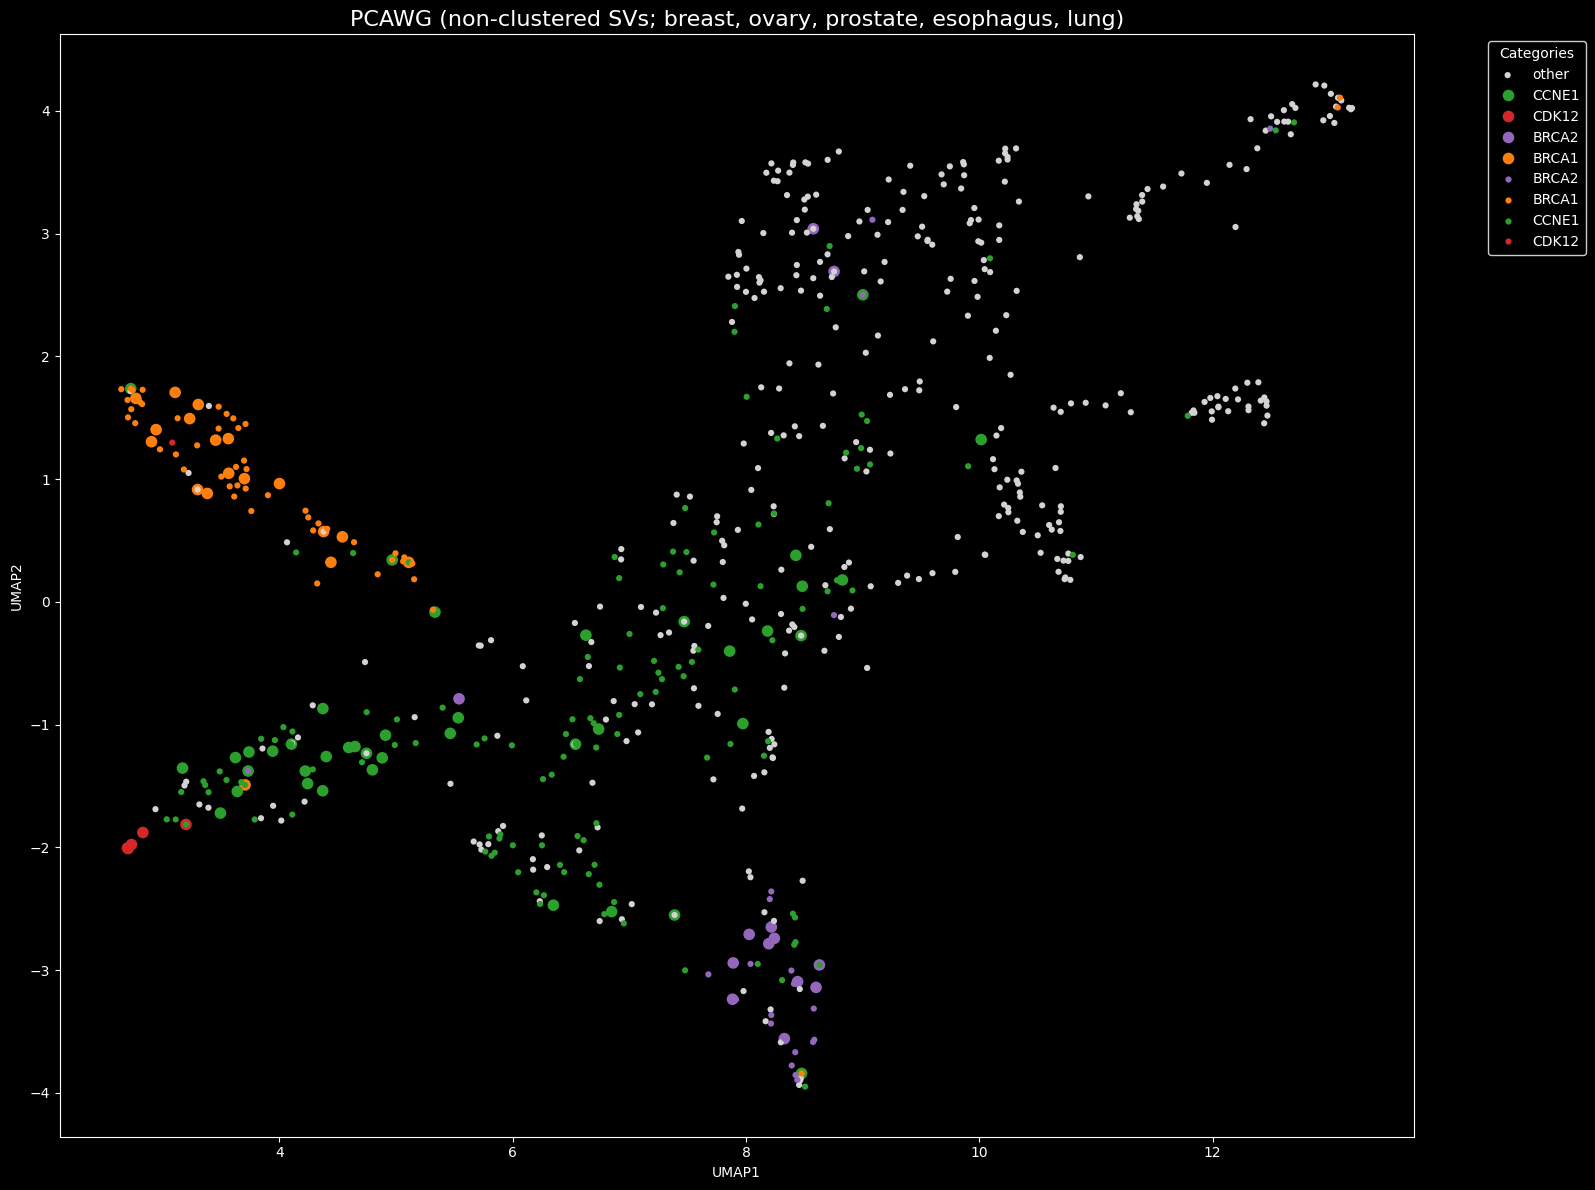

In [55]:
plt.style.use("dark_background")
plt.rcParams.update({
    "axes.facecolor": "black",
    "figure.facecolor": "black",
    "axes.edgecolor": "white",
    "axes.labelcolor": "white",
    "xtick.color": "white",
    "ytick.color": "white",
    "text.color": "white",
    "legend.edgecolor": "white",
    "legend.facecolor": "black",
    "savefig.facecolor": "black",
    "savefig.edgecolor": "black",
})
# --- Plot ---
plt.figure(figsize=(16, 12))

if rowLabels is not None:
    # Split into "other" and "non-other"
    df_other = umap_df[umap_df['label'] == "other"]
    df_non_other = umap_df[umap_df['label'] != "other"]
    df_mutant = umap_df[umap_df['true_label'] != "other"]
    

    plt.scatter(
        df_other['UMAP1'],
        df_other['UMAP2'],
        s=20,
        facecolors='lightgray',
        edgecolors='none',
        linewidth=0.8,
        label='other',
        zorder=2
    )

    sns.scatterplot(
        data=df_mutant,
        x='UMAP1',
        y='UMAP2',
        hue='true_label',
        palette={k: v for k, v in lut.items() if k != "other"},
        s=70,
        edgecolor='none',
        linewidth=0,
        legend=True,
        zorder=1
    )


    # Plot all non-"other" points on top
    sns.scatterplot(
        data=df_non_other,
        x='UMAP1',
        y='UMAP2',
        hue='label',
        palette={k: v for k, v in lut.items() if k != "other"},
        s=20,
        edgecolor='none',
        linewidth=0,
        legend=True,
        zorder=3
    )




    plt.legend(title="Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

else:
    plt.scatter(umap_df['UMAP1'], umap_df['UMAP2'], s=50, color='grey')

plt.title("PCAWG (non-clustered SVs; breast, ovary, prostate, esophagus, lung)", fontsize=16)
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.tight_layout()

# ✅ Save Illustrator-editable vector PDF
output_path = f"{output_dir}/umap_projection_loo_bw.pdf"
plt.savefig(output_path, format='pdf')
print(f"Saved Illustrator-editable PDF: {output_path}")

plt.show()

In [37]:
X_np

array([[ 0.        ,  0.        ,  0.        , ...,  2.10160552,
         0.        ,  2.42346432],
       [ 0.90820957,  2.9799949 ,  0.        , ...,  0.        ,
         0.80391123,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., 13.30138771,
        13.72823293,  0.        ],
       ...,
       [ 1.6664444 ,  5.02348941,  0.        , ..., 13.93112194,
        20.09524853,  0.        ],
       [ 0.        ,  1.1533794 ,  0.        , ...,  0.        ,
         0.        ,  5.53426508],
       [ 2.16780607,  5.08392356,  0.        , ...,  3.09195606,
         3.56693023,  5.43885654]], shape=(631, 33))

In [38]:

# Let SHAP know which function produces outputs
explainer = shap.Explainer(clf.predict_proba, X_np)

# Compute SHAP values
shap_values = explainer(X_np)

PermutationExplainer explainer: 632it [00:35, 15.16it/s]                        


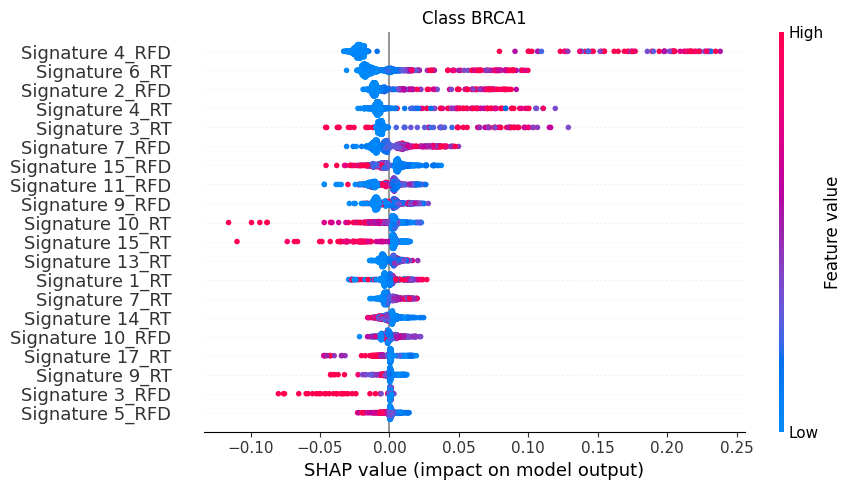

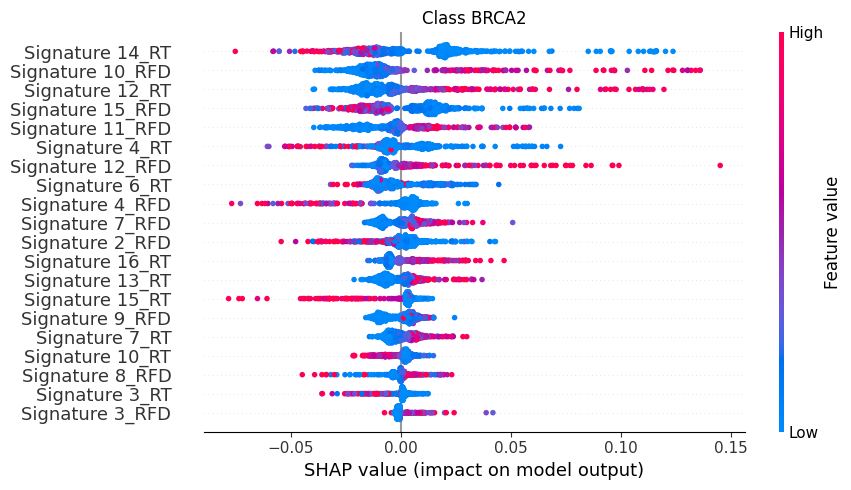

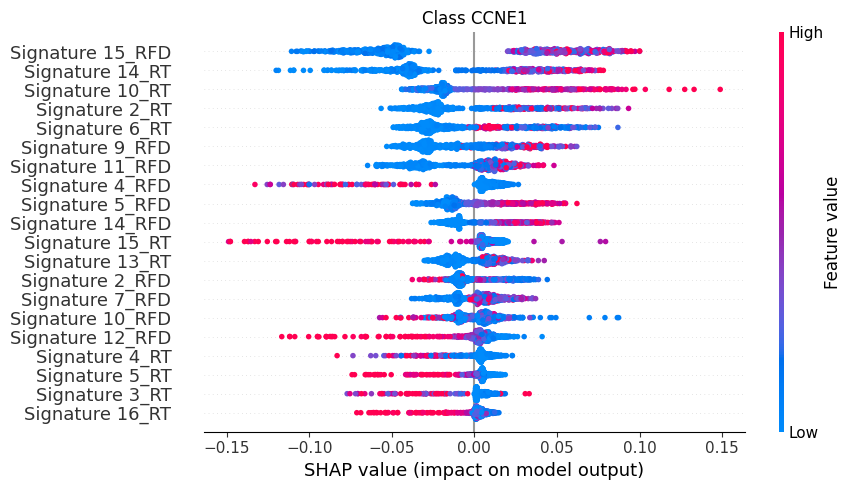

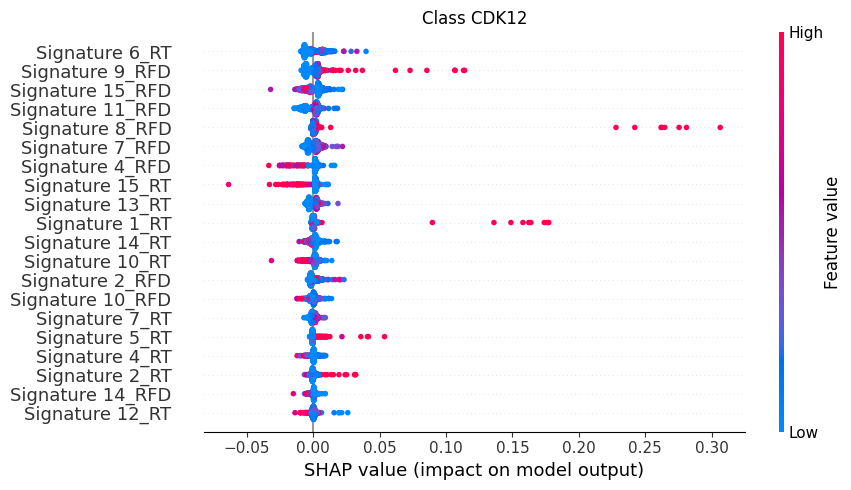

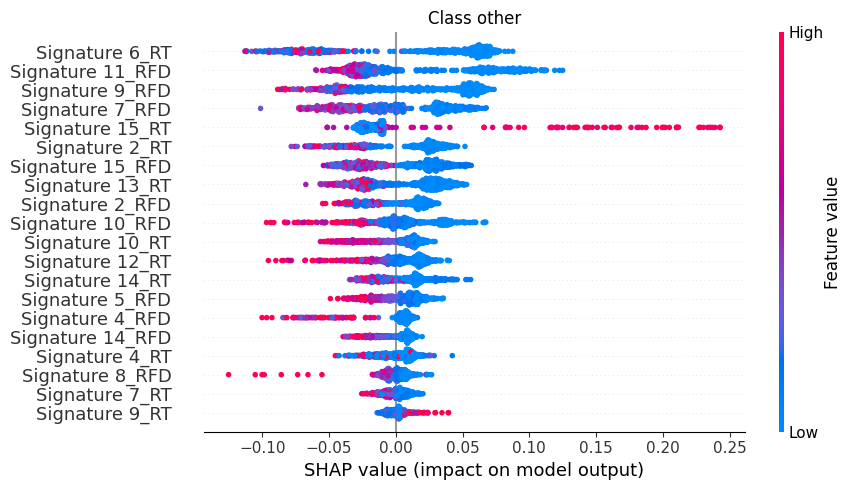

<Figure size 640x480 with 0 Axes>

In [39]:
plt.style.use('default')
plt.rcdefaults()

# this is for the second model
rng = np.random.default_rng(42)  # reproducible RNG

n_classes = shap_values.values.shape[-1]
n_cols = 3
n_rows = int(np.ceil(n_classes / n_cols))

rng = np.random.default_rng(42)  # reproducible RNG


for c in range(n_classes):
    shap.summary_plot(shap_values.values[..., c], X, show=False,
        rng=rng)
    plt.title(f"Class {le.classes_[c]}")
    plt.gcf().set_size_inches(9, 5)  # adjust width manually per plot
    plt.tight_layout()
    plt.show()

plt.tight_layout()

In [40]:
output_dir

'/home/dg204/park_dglodzik/SVsigs/classifier/PCAWG_training/'

In [41]:


# --- reproducible RNG ---
rng = np.random.default_rng(42)

# --- setup output directory ---

n_classes = shap_values.values.shape[-1]

for c in range(n_classes):
    # Generate SHAP summary plot for each class
    shap.summary_plot(
        shap_values.values[..., c],
        X,
        show=False,
        rng=rng
    )

    # Title and layout
    plt.title(f"Class {le.classes_[c]}", fontsize=14)
    plt.gcf().set_size_inches(9, 5)
    plt.tight_layout()

    # Save as vector PDF (Illustrator-friendly)
    filename = os.path.join(output_dir, f"shap_summary_{le.classes_[c]}.pdf")
    plt.savefig(filename, format="pdf", bbox_inches="tight")

    plt.close()  # close figure before next loop

print(f"✅ Saved {n_classes} SHAP summary plots to '{output_dir}/' as separate PDFs.")

✅ Saved 5 SHAP summary plots to '/home/dg204/park_dglodzik/SVsigs/classifier/PCAWG_training//' as separate PDFs.


In [42]:
c

4